<a href="https://colab.research.google.com/github/kesarwanisiddhika59-a11y/DAA--PRACTICAL-/blob/main/Stock_market.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install yfinance seaborn -q


In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("darkgrid")


In [3]:
# Choose stock
ticker = "RELIANCE.NS"

# Download data
data = yf.download(
    ticker,
    start="2020-01-01",
    end="2025-01-01",
    auto_adjust=True
)

# Display data
data.head()


[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,
2020-01-01,672.216248,680.008913,670.390593,675.956732,14004468
2020-01-02,683.660278,686.176208,673.284921,673.284921,17710316
2020-01-03,684.484070,686.487896,678.183128,682.636062,20984698
2020-01-06,668.609314,680.365044,667.050769,676.847260,24519177
2020-01-07,678.895691,683.304098,673.952887,676.401995,16683622


In [4]:
print("Shape of dataset:", data.shape)
print("\nColumns:")
print(data.columns)

print("\nMissing values:")
print(data.isnull().sum())

print("\nBasic statistics:")
display(data.describe())


Shape of dataset: (1238, 5)

Columns:
MultiIndex([( 'Close', 'RELIANCE.NS'),
            (  'High', 'RELIANCE.NS'),
            (   'Low', 'RELIANCE.NS'),
            (  'Open', 'RELIANCE.NS'),
            ('Volume', 'RELIANCE.NS')],
           names=['Price', 'Ticker'])

Missing values:
Price   Ticker     
Close   RELIANCE.NS    0
High    RELIANCE.NS    0
Low     RELIANCE.NS    0
Open    RELIANCE.NS    0
Volume  RELIANCE.NS    0
dtype: int64

Basic statistics:


Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
count,1238.000000,1238.000000,1238.000000,1238.000000,1.238000e+03
mean,1095.098188,1107.006456,1084.237082,1095.962058,1.951391e+07
std,230.477780,230.698652,230.092007,230.365315,1.612248e+07
min,393.662384,423.029534,389.921900,407.978572,1.705656e+06
25%,951.000824,962.121205,942.435904,951.571329,1.009199e+07
50%,1115.586792,1127.810013,1106.010452,1116.995483,1.425293e+07
75%,1219.325256,1232.958550,1207.933226,1219.190640,2.203644e+07
max,1581.824463,1589.630354,1566.607850,1585.332001,1.426834e+08


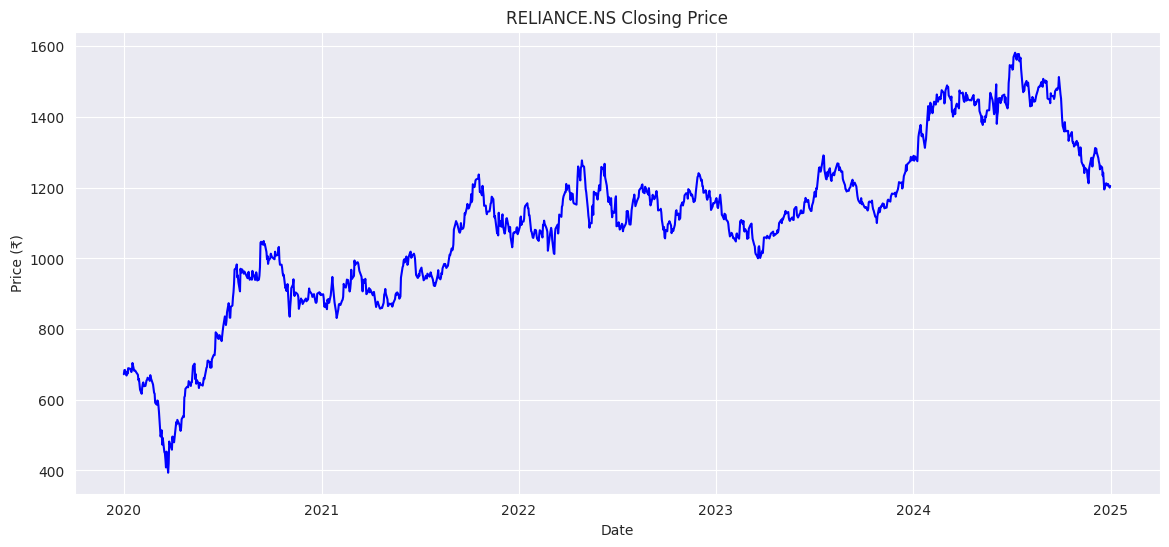

In [5]:
plt.figure(figsize=(14, 6))

plt.plot(data["Close"], color="blue")

plt.title(f"{ticker} Closing Price")
plt.xlabel("Date")
plt.ylabel("Price (₹)")

plt.show()


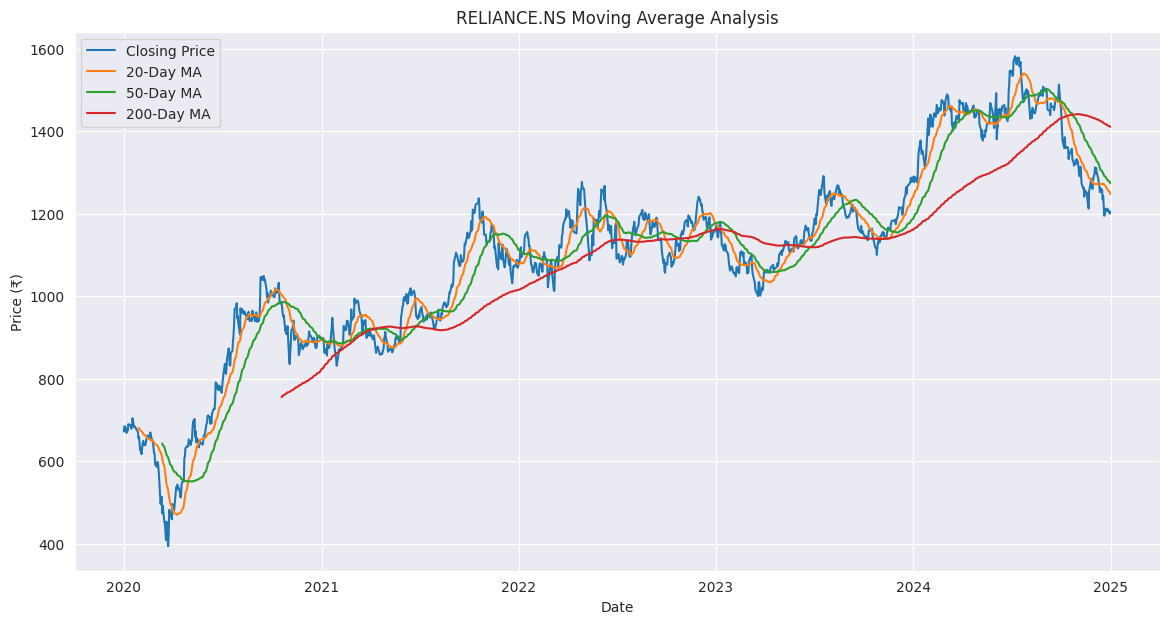

In [6]:
data["MA20"] = data["Close"].rolling(20).mean()
data["MA50"] = data["Close"].rolling(50).mean()
data["MA200"] = data["Close"].rolling(200).mean()

plt.figure(figsize=(14, 7))

plt.plot(data["Close"], label="Closing Price")
plt.plot(data["MA20"], label="20-Day MA")
plt.plot(data["MA50"], label="50-Day MA")
plt.plot(data["MA200"], label="200-Day MA")

plt.title(f"{ticker} Moving Average Analysis")
plt.xlabel("Date")
plt.ylabel("Price (₹)")
plt.legend()

plt.show()


In [7]:
data["Daily_Return"] = data["Close"].pct_change()

display(data[["Close", "Daily_Return"]].tail())


Price,Close,Daily_Return
Ticker,RELIANCE.NS,
Date,,
2024-12-24,1212.280884,0.000368
2024-12-26,1206.133911,-0.005071
2024-12-27,1210.595459,0.003699
2024-12-30,1200.333862,-0.008476
2024-12-31,1205.043213,0.003923


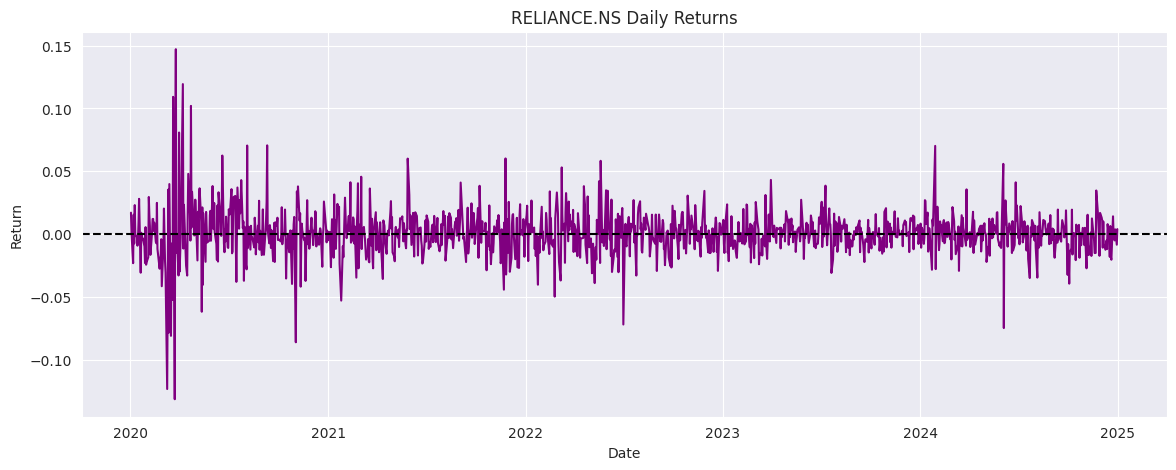

In [8]:
plt.figure(figsize=(14, 5))

plt.plot(
    data["Daily_Return"],
    color="purple"
)

plt.axhline(0, color="black", linestyle="--")

plt.title(f"{ticker} Daily Returns")
plt.xlabel("Date")
plt.ylabel("Return")

plt.show()


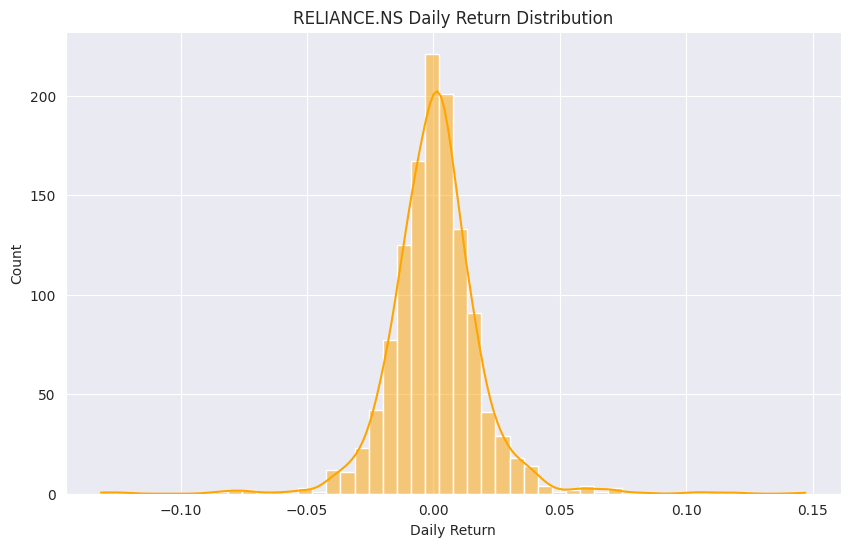

In [9]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data["Daily_Return"].dropna(),
    bins=50,
    kde=True,
    color="orange"
)

plt.title(f"{ticker} Daily Return Distribution")
plt.xlabel("Daily Return")

plt.show()


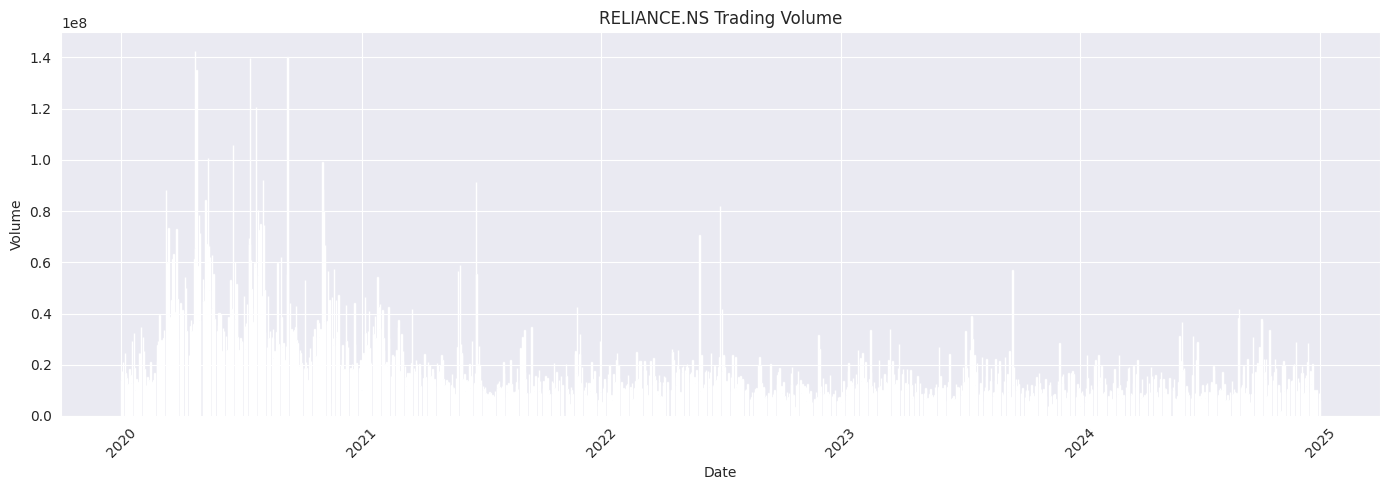

In [12]:
volume = data[("Volume", ticker)]

plt.figure(figsize=(14, 5))

plt.bar(data.index, volume, color="steelblue")

plt.title(f"{ticker} Trading Volume")
plt.xlabel("Date")
plt.ylabel("Volume")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [13]:
daily_volatility = data["Daily_Return"].std()
annual_volatility = daily_volatility * np.sqrt(252)

print("Daily Volatility:", round(daily_volatility, 4))
print("Annualized Volatility:", round(annual_volatility, 4))


Daily Volatility: 0.0187
Annualized Volatility: 0.2973


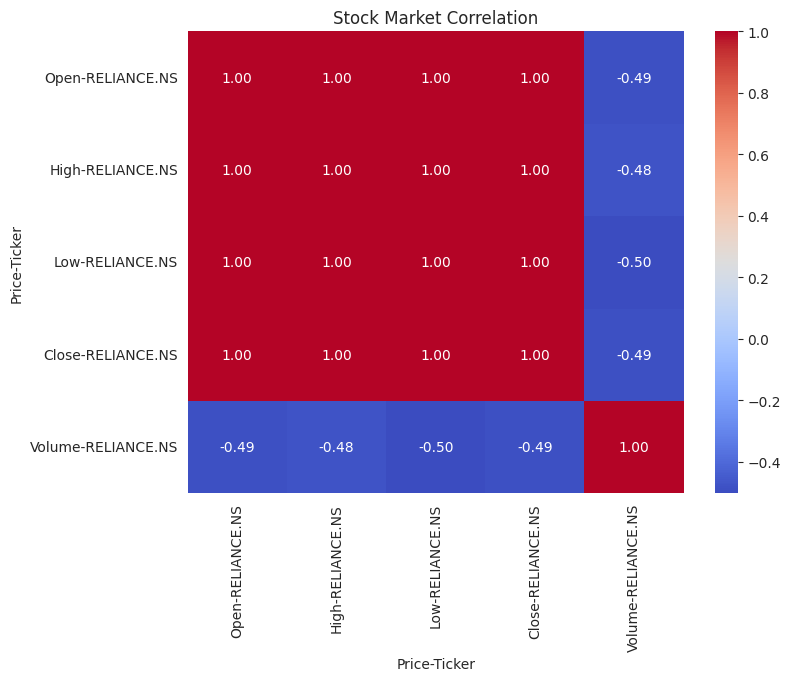

In [14]:
correlation_data = data[
    ["Open", "High", "Low", "Close", "Volume"]
].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_data,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Stock Market Correlation")

plt.show()


In [15]:
data.to_csv("RELIANCE_stock_analysis.csv")

print("Dataset saved successfully!")


Dataset saved successfully!
